In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import torch
from torch import nn
from torch.nn import functional as F
from tqdm import tqdm
from linformer import Linformer
from vit_pytorch.efficient import ViT
from vit_pytorch import SimpleViT
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

Load the data

In [2]:
connectome_data = pd.read_csv("../../Dataset/widsdatathon2025/TRAIN_NEW/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv")

In [3]:
train_labels = pd.read_excel("../../Dataset/widsdatathon2025/TRAIN_NEW/TRAINING_SOLUTIONS.xlsx")

In [4]:
# split the data into 4 splits
train_labels_adhd_male = train_labels[(train_labels["ADHD_Outcome"] == 1) & (train_labels["Sex_F"] == 0)] 
train_labels_adhd_female = train_labels[(train_labels["ADHD_Outcome"] == 1) & (train_labels["Sex_F"] == 1)] 
train_labels_no_adhd_male = train_labels[(train_labels["ADHD_Outcome"] == 0) & (train_labels["Sex_F"] == 0)] 
train_labels_no_adhd_female = train_labels[(train_labels["ADHD_Outcome"] == 0) & (train_labels["Sex_F"] == 1)] 

In [5]:
connectome_data_adhd_male = connectome_data[connectome_data['participant_id'].isin(train_labels_adhd_male['participant_id'])]
connectome_data_adhd_female = connectome_data[connectome_data['participant_id'].isin(train_labels_adhd_female['participant_id'])]
connectome_data_no_adhd_male = connectome_data[connectome_data['participant_id'].isin(train_labels_no_adhd_male['participant_id'])]
connectome_data_no_adhd_female = connectome_data[connectome_data['participant_id'].isin(train_labels_no_adhd_female['participant_id'])]

In [6]:
expected_num_regions = 200

Build Adjacency matrices for 4 classes - ADHD (male), ADHD (female), No ADHD (male), No ADHD (female)

In [7]:
def construct_adjacency_matrix(connectome_data):
    connectivity_vectors = connectome_data.iloc[:, 1:].values
    num_patients = connectome_data.shape[0]

    upper_tri_indices = np.triu_indices(expected_num_regions, k=1)

    matrix_full = np.zeros((num_patients, expected_num_regions, expected_num_regions))

    for i in range(num_patients):
        matrix = np.zeros((expected_num_regions, expected_num_regions))
        matrix[upper_tri_indices] = connectivity_vectors[i]  
        matrix += matrix.T 
        np.fill_diagonal(matrix, 0)  
        matrix_full[i] = matrix

    return matrix_full  

In [8]:
matrix_adhd_male = construct_adjacency_matrix(connectome_data_adhd_male)
matrix_adhd_female = construct_adjacency_matrix(connectome_data_adhd_female)
matrix_no_adhd_male = construct_adjacency_matrix(connectome_data_no_adhd_male)
matrix_no_adhd_female = construct_adjacency_matrix(connectome_data_no_adhd_female)

In [9]:
print(matrix_adhd_male.shape)
print(matrix_adhd_female.shape)
print(matrix_no_adhd_male.shape)
print(matrix_no_adhd_female.shape)

(581, 200, 200)
(250, 200, 200)
(216, 200, 200)
(166, 200, 200)


<Axes: >

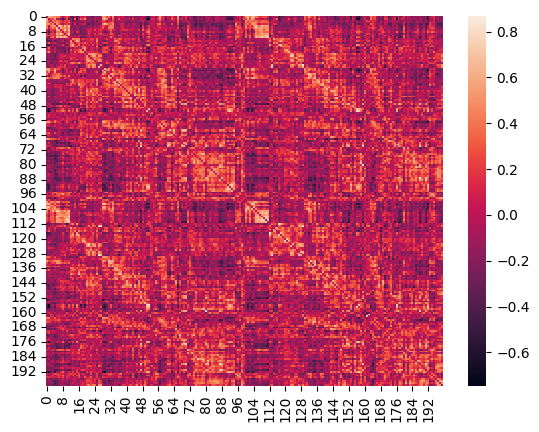

In [10]:
sns.heatmap(matrix_adhd_female[0])

In [11]:
combined_matrix_dataset = list(matrix_adhd_female) + list(matrix_adhd_male) + list(matrix_no_adhd_female) + list(matrix_no_adhd_male)
combined_matrix_dataset = np.array(combined_matrix_dataset)

In [12]:
labels = [1] * 831 + [0] * 382

In [13]:
combined_matrix_dataset.shape

(1213, 200, 200)

Dataset Class

In [14]:
class ConnectomeMapDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        self.filelength = len(self.files)
        return self.filelength

    def __getitem__(self, idx):
        file = self.files[idx]
        file = file.reshape((1, file.shape[0], file.shape[1]))

        label = self.labels[idx]
        # label = np.array([label])

        return file, label


In [15]:
train_list, test_list, train_labels, test_labels = train_test_split(combined_matrix_dataset, labels, test_size=0.2, random_state=42, shuffle=True)


In [16]:
train_data = ConnectomeMapDataset(train_list, train_labels)
test_data = ConnectomeMapDataset(test_list, test_labels)

In [17]:
# Training settings
batch_size = 64
epochs = 100
lr = 3e-5
gamma = 0.7
seed = 42

In [18]:
train_loader = DataLoader(dataset = train_data, batch_size=batch_size, shuffle=True )
test_loader = DataLoader(dataset = test_data, batch_size=batch_size, shuffle=True)

In [19]:
print(len(train_data), len(train_loader))

970 16


In [20]:
print(len(test_data), len(test_loader))

243 4


Model

In [21]:
device = 'mps'

In [22]:
efficient_transformer = Linformer(
    dim=128,
    seq_len=100+1,  # 7x7 patches + 1 cls-token
    depth=12,
    heads=8,
    k=64
)

In [23]:
model = ViT(
    dim=128,
    image_size=200,
    patch_size=20,
    num_classes=1,
    transformer=efficient_transformer,
    channels=1,
).to(device)

In [24]:
# model = SimpleViT(
#     dim=128,
#     image_size=224,
#     patch_size=32,
#     num_classes=2,
#     channels=3,
#     depth=12,
#     heads=8,
#     mlp_dim=2048
# ).to(device)

In [25]:
# loss function
# criterion = nn.CrossEntropyLoss()
criterion = nn.BCELoss()
# optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)
# scheduler
scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

In [31]:
for epoch in range(epochs):
    epoch_loss = 0
    epoch_accuracy = 0

    for data, label in tqdm(train_loader):
        data = data.type(torch.float32)
        label = label.type(torch.float32)
        data = data.to(device)
        label = label.to(device)

        # label = label.type(torch.LongTensor)
        # label = F.one_hot(label, num_classes=2)
        # label = label.type(torch.float32).to(device)

        output = model(data)
        output = output.squeeze()
        # print(output.shape)
        # print(label.shape)
        loss = criterion(output, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # acc = (output.argmax(dim=1) == label.argmax(dim=1)).float().mean()
        output = (output > 0.5).type(torch.float32)
        acc = (output == label).float().mean()

        epoch_accuracy += acc / len(train_loader)
        epoch_loss += loss / len(train_loader)

    with torch.no_grad():
        epoch_val_accuracy = 0
        epoch_val_loss = 0
        for data, label in test_loader:
            data = data.type(torch.float32)
            label = label.type(torch.float32)
            data = data.to(device)
            label = label.to(device)

            # label = label.type(torch.LongTensor)
            # label = F.one_hot(label, num_classes=2)
            # label = label.type(torch.float32).to(device)

            val_output = model(data)
            val_output = val_output.squeeze()
            val_loss = criterion(val_output, label)

            # acc = (val_output.argmax(dim=1) == label.argmax(dim=1)).float().mean()
            val_output = (val_output > 0.5).type(torch.float32)
            acc = (val_output == label).float().mean()
            epoch_val_accuracy += acc / len(test_loader)
            epoch_val_loss += val_loss / len(test_loader)

    print(
        f"Epoch : {epoch+1} - loss : {epoch_loss:.4f} - acc: {epoch_accuracy:.4f} - val_loss : {epoch_val_loss:.4f} - val_acc: {epoch_val_accuracy:.4f}\n"
    )


100%|██████████| 16/16 [00:01<00:00,  9.69it/s]


Epoch : 1 - loss : 0.5398 - acc: 0.7281 - val_loss : 0.5960 - val_acc: 0.7262



100%|██████████| 16/16 [00:01<00:00, 10.10it/s]


Epoch : 2 - loss : 0.5427 - acc: 0.7133 - val_loss : 0.7997 - val_acc: 0.4761



100%|██████████| 16/16 [00:01<00:00,  9.79it/s]


...

Epoch : 9 - loss : 0.2050 - acc: 0.9199 - val_loss : 1.0186 - val_acc: 0.7028



100%|██████████| 16/16 [00:01<00:00, 10.13it/s]


Epoch : 10 - loss : 0.1775 - acc: 0.9336 - val_loss : 1.1356 - val_acc: 0.5728



 62%|██████▎   | 10/16 [00:01<00:00,  9.19it/s]


KeyboardInterrupt: 